In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
sns.set_style("darkgrid")

from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from time import time

from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


In [3]:
train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'

In [4]:
horizon = 144
historical_data_window = 336  # 24 hours * 2 (30-minute intervals)

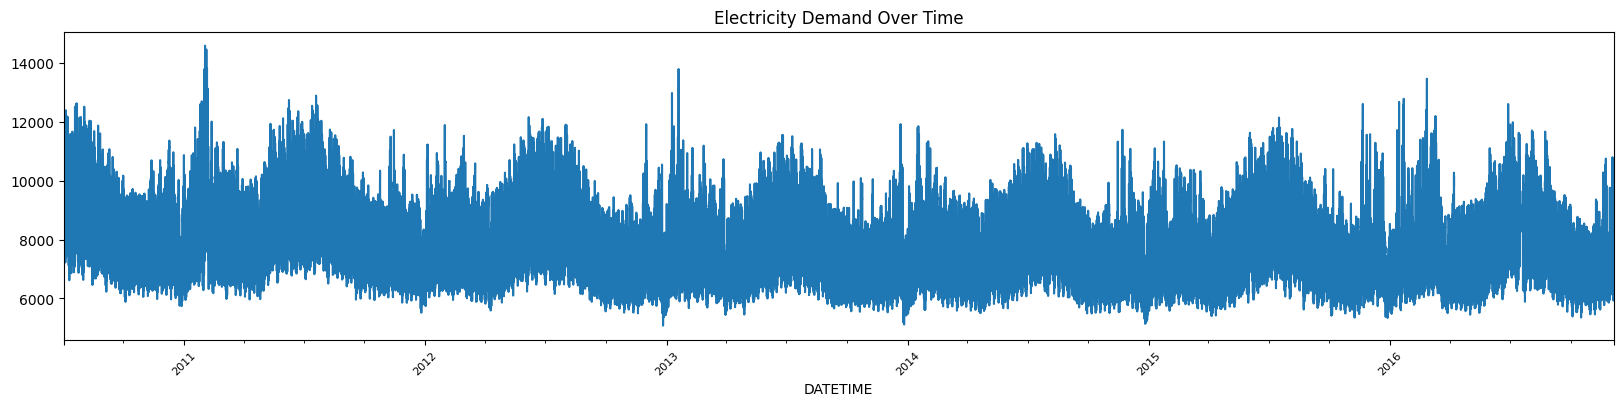

In [5]:
subset_train = train#[train.index.max() - pd.Timedelta(hours=historical_data_window/2):]
subset_train['TOTALDEMAND'].plot(figsize=(20,4), title='Electricity Demand Over Time')
#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(rotation=45, fontsize=8)
plt.show()

## Autoregressive Forecast Model

To figure out order of AR, we use the PACF rathern than just ACF. Partial Auto-correlation Function and Auto-correlation Function.

Recall, ACF does NOT account for the correlation conditioned (or "given indirectly") by other lags.

e.g. S_t, S_t-1, S_t-2:
corr(S_t, S_t-2) might be affected by S_t-1, and this does not "remove" this effect. It includes it. Meaning if u included all 3, u might have multicollinearity.

partial_corr(S_t, S_t-2) though would "remove" the effect from S_t-1, so it only gives you the direct corr between S_t and S_t-2 (see multivariate course).

In [ ]:
acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(100, len(subset_train)-1))

In [ ]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(336, len(subset_train)/2-1))

In [ ]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

Stationarity includes 3 conditions of a time-series variable:
* constant mean
* constant variance
* NO seasonality (should look like a sine/cosine plot)

In [ ]:
start = time()
desired_lags = 60
order_num = min(desired_lags, (len(subset_train)-1) // 2)  # Ensure we don't exceed data limits
print(order_num)
model = ARIMA(subset_train['TOTALDEMAND'], order=(order_num,0,0), enforce_stationarity=True, enforce_invertibility=True)
model_fit = model.fit()
end = time()
print(f"Model fitting took {end - start:.2f} seconds")

In [ ]:
# from statsmodels.tsa.ar_model import AutoReg

# model2 = AutoReg(subset_train['TOTALDEMAND'], lags=desired_lags)
# model_fit2 = model.fit() # runs faster

In [ ]:
print(model_fit.summary())

In [ ]:
validation_target = validation['TOTALDEMAND'].iloc[:horizon+1]
validation_target.index.min(), validation_target.index.max()

In [ ]:
predictions = model_fit.predict(start=validation_target.index[0], end=validation_target.index[-1])
residuals = validation_target - predictions
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of ARIMA({order_num},0,0) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[horizon], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()
plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[horizon], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(validation_target, predictions)
rmse = root_mean_squared_error(validation_target, predictions)
print(f"ARIMA({order_num},0,0) Validation MSE: {mse:.2f}")
print(f"ARIMA({order_num},0,0) Validation RMSE: {rmse:.2f}")

## Moving Average Forecast Model

First, note the LAG you choose to fit your MA model would restrict you from making predictions MORE than that lag. Any horizon that exceeds that lag will just predict the mean of those future horizons.

forecast = mean + coeff_lag_1 * err_lag_1 + coeff_lag_2 * err_lag_2 + ...

where err ~ N(mu,sigma), i.i.d.


To figure out order of MA, we use the ACF. 

In [ ]:
acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(500, len(subset_train)-1))
plt.title('ACF of Electricity Demand')

In [ ]:
order_num_ma = 48

In [ ]:
horizon

Invertibility

Why does MA(1) model really just equal to AR(inf) model and vice versa (IFF)?


In [ ]:
model_ma = ARIMA(subset_train['TOTALDEMAND'], order=(0,0,order_num_ma), enforce_stationarity=True, enforce_invertibility=True)
start = time()
model_fit_ma = model_ma.fit()
end = time()
print(f"MA({order_num_ma}) Model fitting took {end - start:.2f} seconds")
print(model_fit_ma.summary())

In [ ]:
validation_target = validation['TOTALDEMAND'].iloc[:order_num+1]
validation_target.index.min(), validation_target.index.max()

In [ ]:
predictions = model_fit_ma.predict(start=validation_target.index[0], end=validation_target.index[-1])
residuals = validation_target - predictions
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of ARIMA(0,0,{order_num_ma}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(validation_target, predictions)
rmse = root_mean_squared_error(validation_target, predictions)
print(f"ARIMA({order_num},0,0) Validation MSE: {mse:.2f}")
print(f"ARIMA({order_num},0,0) Validation RMSE: {rmse:.2f}")

## ARIMA Model (Autoregressive Integrated Moving Average Model)

There is a new parameter. Originally there was P for AR and Q for MA.

p for AR means the number of lag steps to include in the AR portion and Q was for the number of lag steps for MA.

Now there is an I parameter. This I is use to "remove" a non-constant mean, since this is a requirement for AR and MA models (or ARMA model).
It does this by creating a new dataset from the original time series.

For example, let A_t and A_t-1 be 2 time steps of the original time series. If there is non-constant mean, that means there is a "slope" trend of some sort, and this "slope" is likely a constant. Specifically, the difference of values in timestamp t-1 and t, is that constant (over simplification by to illustrate the idea), and that is the slope.

Thus, if we create a new data point called Z_t = A_t - A_t-1, then we would expect these Z_t to "hover" around that constant (imagine a horizontal trend line now instead of a rising or falling one). This is what the I does. When I = 1, we will be fitting the model to Z_t = A_t - A_t-1. If I = 2 (possibly to fix a quadratically increasing mean), then it would be Z'_t = Z_t - Z_t-1 = (A_t - A_t-1) - (A_t-1 - A_t-2), etc.

In [ ]:
subset_train = train[train.index.max() - pd.Timedelta(hours=historical_data_window/2):]
subset_train['TOTALDEMAND'].plot(figsize=(20,4), title='Electricity Demand Over Time')
#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(rotation=45, fontsize=8)
plt.show()

Luckily, this current data doesn't seem like there is much of a moving mean.

## SARIMA (Seasonal ARIMA)

Now, we add seasonality. This now includes a whole new other order tuple, seasonal_order = (p,d,q,s).

What is seasonality? Well it depends on the period we are looking at.

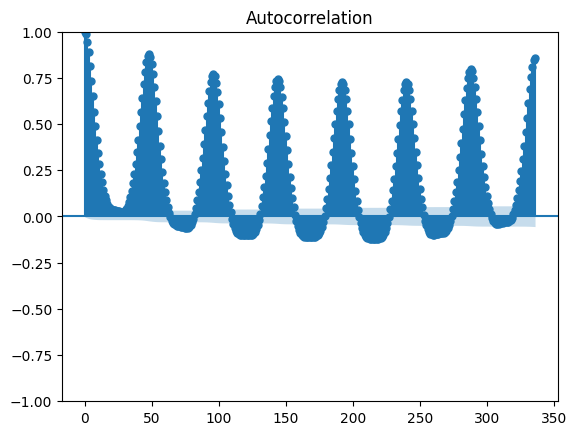

In [6]:
acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(336, len(subset_train)-1))

Here, you can kind of see a correlation repeating every 48 timesteps for AC.

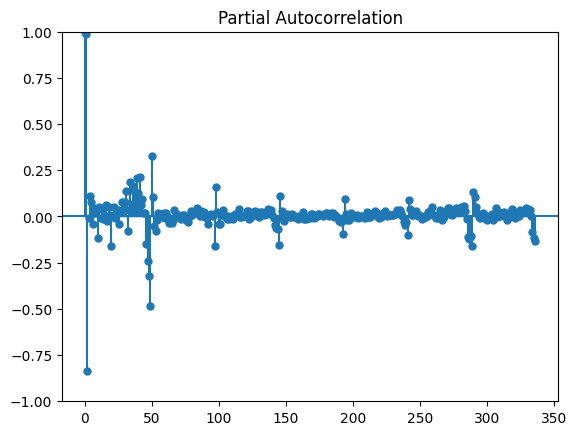

In [7]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(336, len(subset_train)/2-1))

You can also see PAC has a pattern repeating every 48 timesteps.

With repeating patterns every 48 timesteps, we can define our s value as 48: seasonal_order = (p,d,q,48).

Now our ACF showed that this "48 timestep" pattern applies for at least 7 times for the 336 window we plotted for, we might want to include the last 7 "48 timestep" seasonality for the MA (rule of thumb says ACF gives us the order for MA portion, see youtube) parameter, which is q: seasonal_order = (p,d,7,48).

Similarly for PACF, we can set our p to maybe = 5, since it seems to drop off after that: seasonal_order = (5,d,7,48).

Finally, as per the previous part, we do not see much of a moving mean (at least not by 48 timesteps in a 336 timestep window plot). Thus, we can set our d to zero: seasonal_order = (5,0,7,48).

We still need to work-out our regular non-seasonal order though. Let's take a look at the ACF and PACF within a 48 timestep window like before.

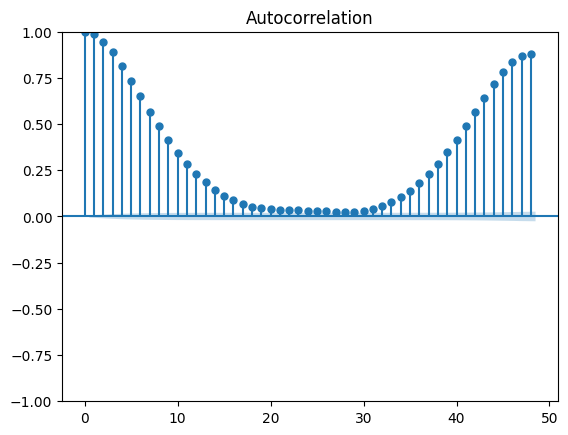

In [8]:
pacf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

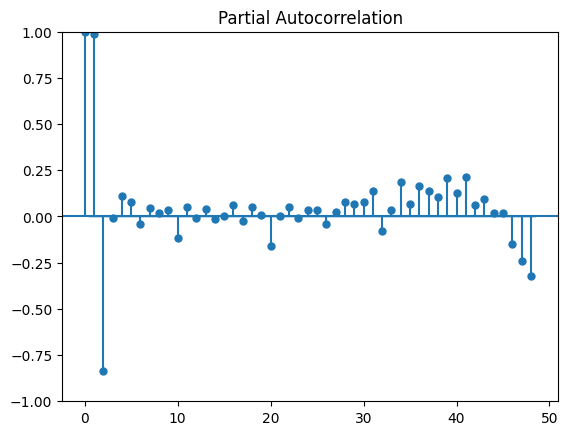

In [9]:
pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

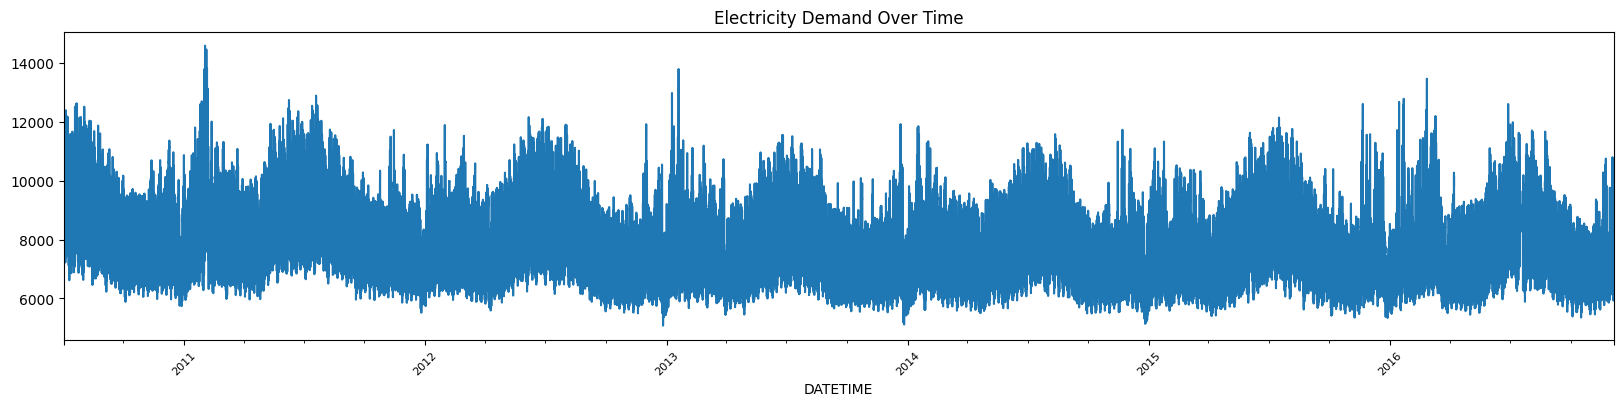

In [11]:
subset_train_ = train#[train.index.max() - pd.Timedelta(hours=24):]
subset_train_['TOTALDEMAND'].plot(figsize=(20,4), title='Electricity Demand Over Time')
#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(rotation=45, fontsize=8)
plt.show()

the ACF seems to have high correlation within 1-10 timestep window and again at 38 to 48. These should have been captured with our seasonal d parameter, so we won't put anything here for d.


The PACF however, has 1,2,3,4 timesteps having very high partial correlation. Suggesting that we should put at least 4 as p in the regular order.

Finally, within 48 timesteps, we do see there is "un-even" mean. Let's use d=1 to try and solve that.

In [13]:
p = 3
d = 0
q = 0
p_s = 2
d_s = 0
q_s = 1
period = 48

model_sarima = SARIMAX(subset_train['TOTALDEMAND'], order=(p,d,q), seasonal_order=(p_s,d_s,q_s,period))
start = time()
model_fit_sarima = model_sarima.fit()
end = time()
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Model fitting took {end - start:.2f} seconds")
print(model_fit_sarima.summary())

SARIMA(3,0,0)(2,0,1,48) Model fitting took 1815.86 seconds
                                      SARIMAX Results                                       
Dep. Variable:                          TOTALDEMAND   No. Observations:               112651
Model:             SARIMAX(3, 0, 0)x(2, 0, [1], 48)   Log Likelihood             -635908.784
Date:                              Sun, 05 Apr 2026   AIC                        1271831.569
Time:                                      09:51:06   BIC                        1271898.993
Sample:                                  07-02-2010   HQIC                       1271851.921
                                       - 12-04-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5514      0.002    693

2016-12-04 09:30:00 2016-12-19 09:30:00


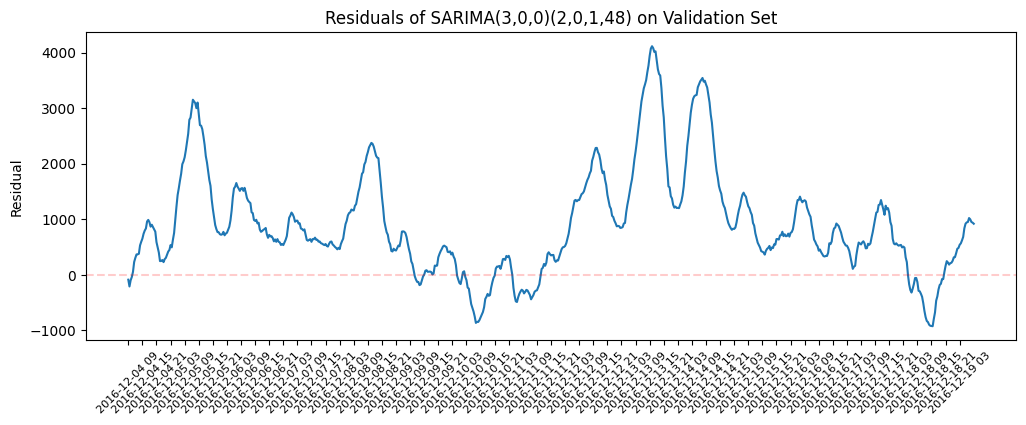

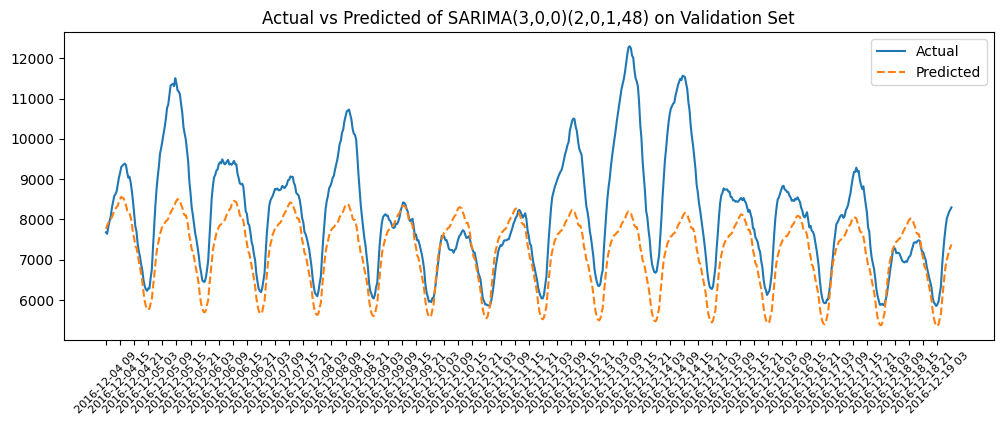

In [23]:
horizon = 720
validation_target = validation['TOTALDEMAND'].iloc[:horizon+1]
print(validation_target.index.min(), validation_target.index.max())
predictions = model_fit_sarima.predict(start=validation_target.index[0], end=validation_target.index[-1])
residuals = validation_target - predictions
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.legend()
plt.show()

In [ ]:
mse = mean_squared_error(validation_target, predictions)
rmse = root_mean_squared_error(validation_target, predictions)
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Validation MSE: {mse:.2f}")
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Validation RMSE: {rmse:.2f}")

SARIMA(4,0,0)(1,1,1,48) Model fitting took 25.34 seconds
                                      SARIMAX Results                                       
Dep. Variable:                          TOTALDEMAND   No. Observations:                  337
Model:             SARIMAX(4, 0, 0)x(1, 1, [1], 48)   Log Likelihood               -1709.225
Date:                              Sun, 05 Apr 2026   AIC                           3432.451
Time:                                      10:00:51   BIC                           3458.116
Sample:                                  11-27-2016   HQIC                          3442.735
                                       - 12-04-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3924      0.039     35.6

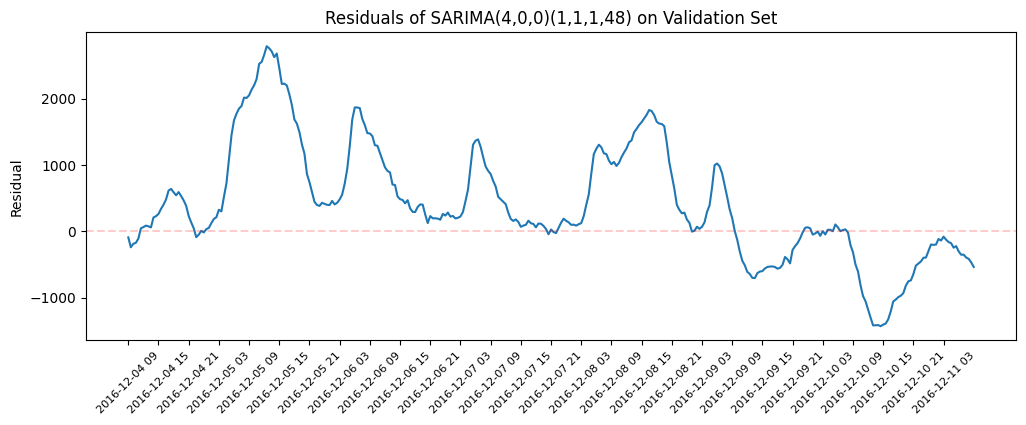

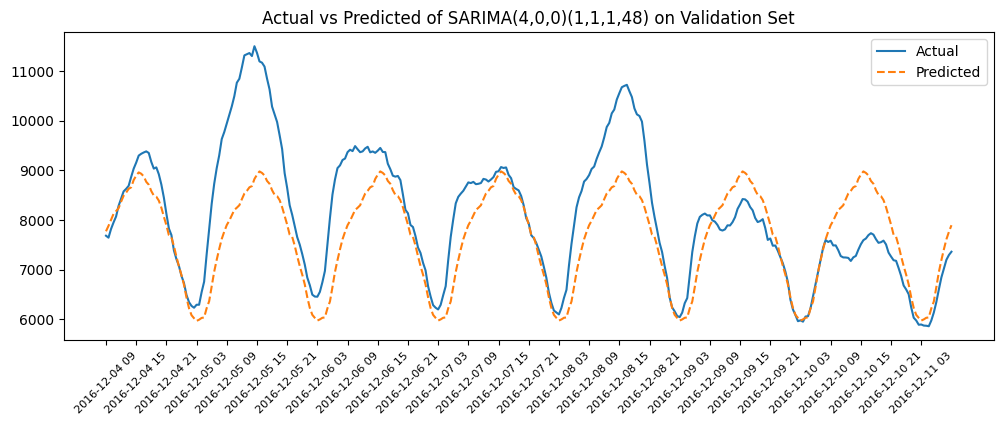

In [28]:
p = 4
d = 0
q = 0
p_s = 1
d_s = 1
q_s = 1
period = 48

lookback_window = 336

subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]

model_sarima = SARIMAX(subset_train['TOTALDEMAND'], order=(p,d,q), seasonal_order=(p_s,d_s,q_s,period))
start = time()
model_fit_sarima = model_sarima.fit()
end = time()
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Model fitting took {end - start:.2f} seconds")
print(model_fit_sarima.summary())


2016-12-04 09:30:00 2016-12-19 09:30:00


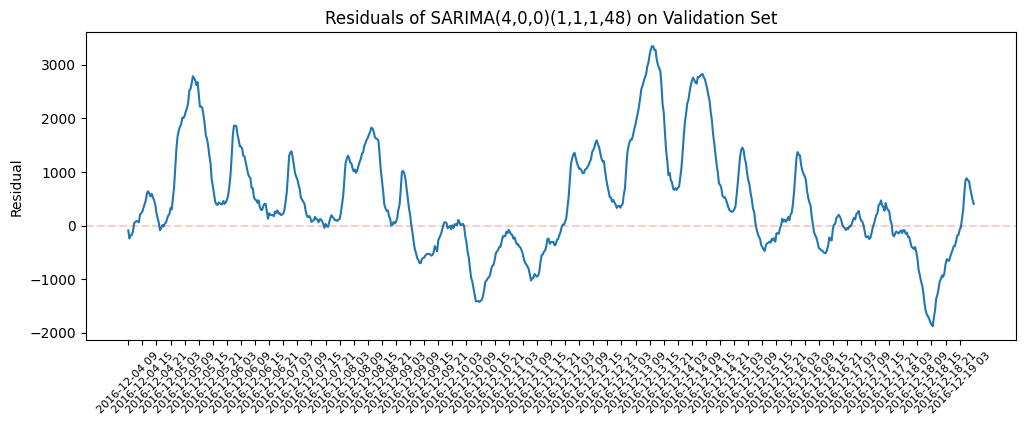

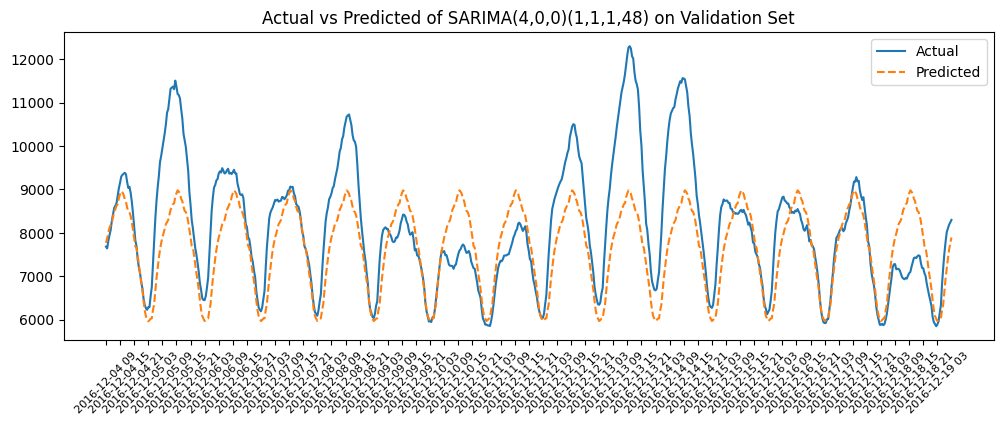

In [30]:
horizon = 720
validation_target = validation['TOTALDEMAND'].iloc[:horizon+1]
print(validation_target.index.min(), validation_target.index.max())
predictions = model_fit_sarima.predict(start=validation_target.index[0], end=validation_target.index[-1])
residuals = validation_target - predictions

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.legend()
plt.show()

## SARIMAX (SARIMA Exogenous variables)

No material from youtube channel.

In [38]:
train['TEMP_SQUARED'] = train['TEMPERATURE'] ** 2
validation['TEMP_SQUARED'] = validation['TEMPERATURE'] ** 2

In [66]:
p = (1,0,1,1)
d = 0
q = 0
p_s = 1
d_s = 1
q_s = 0
period = 48

lookback_window = 720

subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]
exog_feature = ['TEMPERATURE']
model_sarimax = SARIMAX(
    subset_train['TOTALDEMAND'], 
    exog=subset_train[exog_feature], 
    order=(p,d,q), 
    seasonal_order=(p_s,d_s,q_s,period))
model_fit_sarimax = model_sarimax.fit()

print(model_fit_sarimax.summary())

                                         SARIMAX Results                                          
Dep. Variable:                                TOTALDEMAND   No. Observations:                  721
Model:             SARIMAX([1, 3, 4], 0, 0)x(1, 1, 0, 48)   Log Likelihood                   0.000
Date:                                    Sun, 05 Apr 2026   AIC                             12.000
Time:                                            10:42:22   BIC                             39.070
Sample:                                        11-19-2016   HQIC                            22.483
                                             - 12-04-2016                                         
Covariance Type:                                      opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
TEMPERATURE   -55.7742         -0        inf    

c:\Users\kyim1\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse
c:\Users\kyim1\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1431: RuntimeWarning: invalid value encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum
c:\Users\kyim1\Desktop\capstone_project_GroupA\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


2016-12-04 09:30:00 2016-12-19 09:30:00


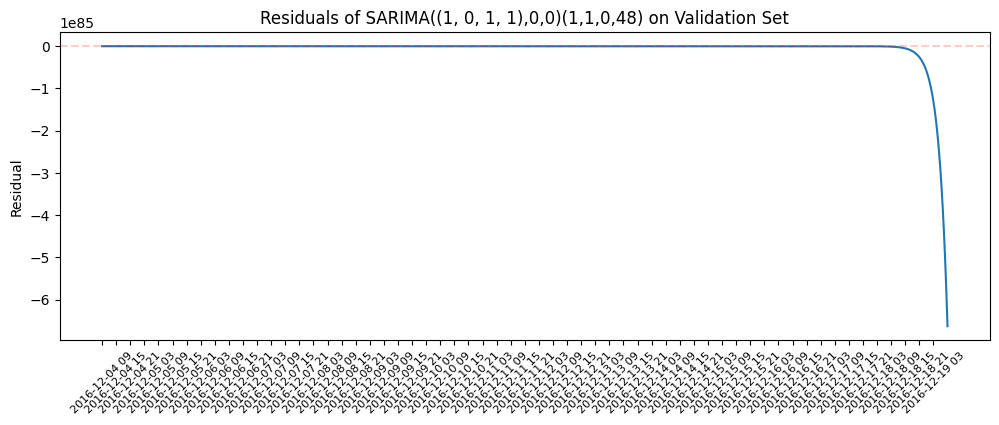

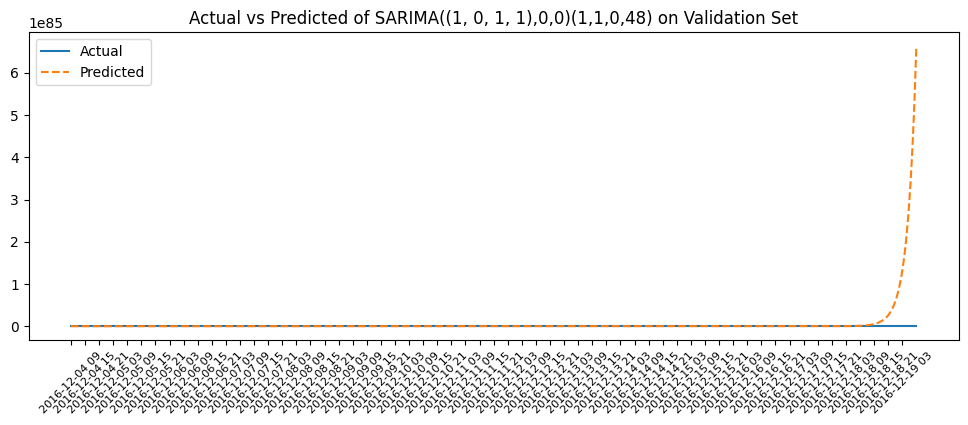

In [67]:
horizon = 720

validation_target = validation['TOTALDEMAND'].iloc[:horizon+1]
print(validation_target.index.min(), validation_target.index.max())
if len(exog_feature) > 0:
    validation_exog = validation[exog_feature].iloc[:horizon+1]
    predictions = model_fit_sarimax.predict(
        start=validation_target.index[0], 
        end=validation_target.index[-1], 
        exog=validation_exog)
else:
    predictions = model_fit_sarimax.predict(
        start=validation_target.index[0], 
        end=validation_target.index[-1])
residuals = validation_target - predictions

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.ylabel('Residual')
# for xticks, show as format 'YYYY-MM-DD HH'
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.axhline(0, color='red', linestyle='--', alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(validation_target, label='Actual')
plt.plot(predictions, label='Predicted', linestyle='--')
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
plt.legend()
plt.show()

AR Model flattens out the further out the horizon. It "flatlines" and we end up predicting just the mean later on. THis is the weakness of this vs ML models.

e.g. "I am going to train on something 7 years in the past, but i'm going to also forecast something 3 years from now. Very difficult."

So what do we do if we want long horizon?

Well, we do not NEED to predict 3 years. We can instead, predict the 1st month, then get the actual data. then predict the 2nd month, and get the actual data... etc. This is called a rolling forecast. i.e. using a rolling forecast origin.

![rollingforecast sarimax.png](<attachment:rollingforecast sarimax.png>)

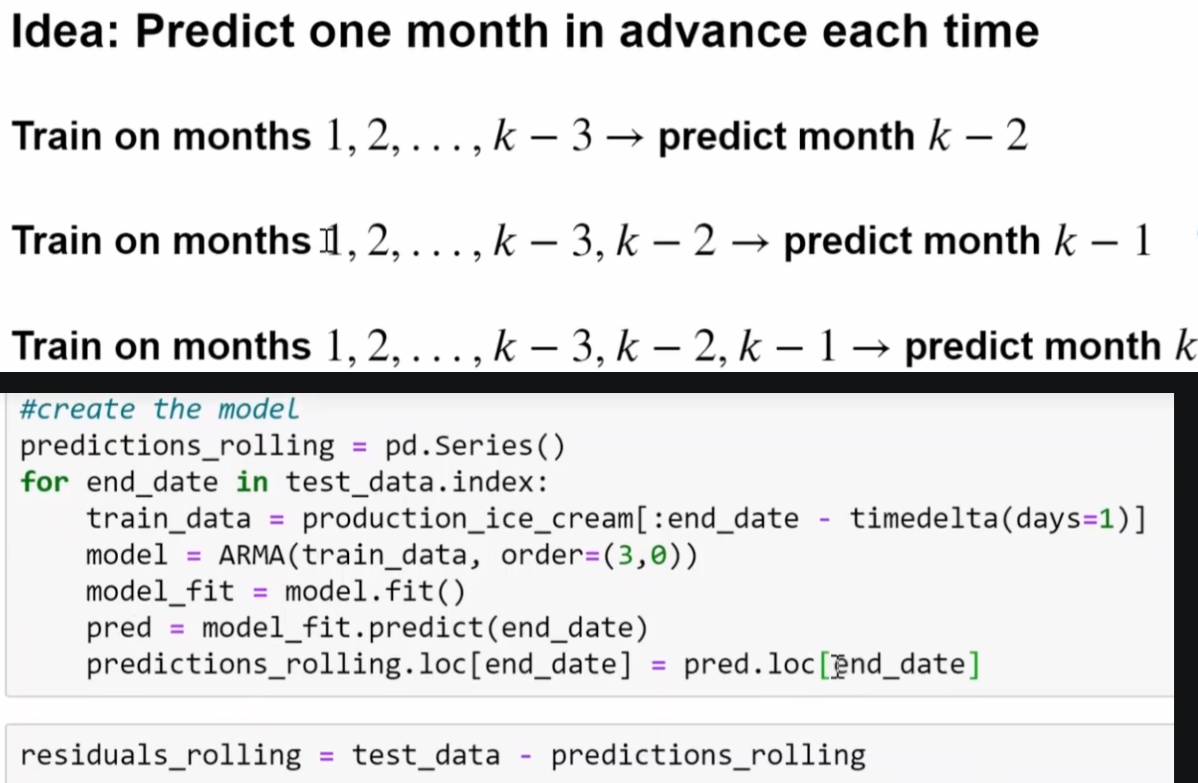

https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_news.html

https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html

this one shows how u can choose specific lags. so u don't have to include all of them.